# Clasificación de texto

> Cómo clasificar documentos con TF-IDF y modelos lineales en un `Pipeline` de scikit-learn: regresión logística, Naive Bayes, SVM lineal y *random forest* comparados en reseñas de Yelp positivas y negativas (con clases desequilibradas) y en noticias de AG News (cuatro clases), con su evaluación: matriz de confusión, precisión, sensibilidad y F1 por clase, curvas ROC y de precisión-sensibilidad, validación cruzada y las palabras que más pesan. Con los errores típicos: fiarse de la exactitud con clases desequilibradas, quitar las negaciones, ajustar el vectorizador antes de separar y evaluar con etiquetas y predicciones desalineadas.
>
> **Requisitos previos:** [Representación vectorial y TF-IDF](03-representacion-vectorial-tfidf.ipynb) · [Flujo de ML y evaluación](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb) · **Relacionado:** [Análisis de sentimientos](07-analisis-de-sentimientos.ipynb) · [Sentimientos con deep learning](08-sentimientos-con-deep-learning.ipynb)

## 1. Idea clave

Clasificar texto es asignar a cada documento una etiqueta: positivo o negativo, spam o no, la sección de un periódico. La receta clásica tiene dos pasos: convertir el texto en un vector con [TF-IDF](03-representacion-vectorial-tfidf.ipynb) y entrenar un clasificador sobre esos vectores. Con miles de dimensiones dispersas y pocos ejemplos por dimensión, los **modelos lineales** (regresión logística, SVM lineal, Naive Bayes) funcionan muy bien: son rápidos, difíciles de sobreajustar con la regularización adecuada e interpretables (cada palabra tiene un peso).

Es la **línea base** que hay que batir antes de usar redes neuronales o [modelos preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb), y muchas veces basta. La parte delicada no es el modelo, sino la **evaluación**: con clases desequilibradas la exactitud engaña, y hay que mirar las métricas por clase, elegir el umbral y comprobar que el preprocesamiento no ha borrado información (como las negaciones) ni se ha filtrado del conjunto de prueba.

## 2. Conceptos importantes

### 2.1. Los clasificadores

Sea $\mathbf{x}$ el vector TF-IDF de un documento e $y \in \{0, 1\}$ su clase.

- **Regresión logística**: estima $P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}\cdot\mathbf{x} + b)$, con $\sigma(z) = 1/(1 + e^{-z})$. Cada palabra tiene un peso $w_j$: positivo si empuja hacia la clase 1. Se entrena minimizando la pérdida logarítmica más una penalización $\lVert\mathbf{w}\rVert^2$, cuyo peso controla `C` (inverso de la regularización).
- **Naive Bayes multinomial**: aplica el teorema de Bayes suponiendo que las palabras son independientes dada la clase: $P(c \mid d) \propto P(c)\prod_{t \in d} P(t \mid c)$, con $P(t \mid c)$ estimada a partir de recuentos, suavizados con `alpha` (Laplace) para que una palabra no vista no anule el producto. Muy rápido y bueno con pocos datos; pensado para **recuentos**, no para TF-IDF.
- **SVM lineal**: busca el hiperplano $\mathbf{w}\cdot\mathbf{x} + b = 0$ que separa las clases con el **margen** máximo (pérdida *hinge*). Suele ser el más preciso con texto; no da probabilidades, sino una puntuación (distancia al hiperplano).
- ***Random forest***: conjunto de árboles de decisión ([bagging y random forest](../04-machine-learning/10-bagging-y-random-forest.ipynb)). Cada división usa una sola palabra, y con decenas de miles de dimensiones dispersas necesita muchos árboles para combinar la evidencia de muchas palabras débiles: con texto suele quedar por detrás de los lineales.

Todos se combinan con el vectorizador en un **`Pipeline`**, para que `fit` ajuste el vocabulario y los pesos solo con los datos de entrenamiento (también dentro de cada pliegue de la validación cruzada).

### 2.2. Métricas

Con la **matriz de confusión** (verdaderos y falsos positivos y negativos: VP, FP, VN, FN) para una clase:

$$
\text{precisión} = \frac{VP}{VP + FP}, \qquad \text{sensibilidad (recall)} = \frac{VP}{VP + FN}, \qquad F_1 = \frac{2\cdot\text{precisión}\cdot\text{sensibilidad}}{\text{precisión} + \text{sensibilidad}}
$$

- **Exactitud** (*accuracy*): proporción de aciertos. Con un 77 % de reseñas positivas, decir siempre «positiva» da un 77 %: con clases desequilibradas no sirve sola.
- **Promedio macro** (*macro average*): media de la métrica de cada clase, todas con el mismo peso. **Ponderado** (*weighted*): cada clase pesa según su tamaño, así que se parece a la exactitud.
- **Curva ROC** y su área (AUC): sensibilidad frente a tasa de falsos positivos al mover el umbral. Mide si el modelo **ordena** bien (AUC = 1, perfecto; 0,5, azar), independientemente del umbral.
- **Curva de precisión-sensibilidad** (PR) y su área (*average precision*): más informativa que la ROC cuando la clase de interés es la minoritaria.

Ver [flujo de ML y evaluación](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb) para la validación cruzada y el resto de métricas.

### 2.3. Clases desequilibradas

Un clasificador que minimiza el error total favorece la clase mayoritaria. Remedios habituales: dar más peso a los errores de la clase minoritaria (`class_weight="balanced"`), **mover el umbral** de decisión (no tiene por qué ser 0,5) o remuestrear ([muestreo y desbalanceo](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb)). Y siempre: evaluar con métricas por clase o macro.

## 3. Código

Dos conjuntos públicos, ambos preparados por Zhang, Zhao y LeCun (2015) y descargados de Hugging Face en `data/`:

- **Yelp Review Full** (conjunto de prueba, 50 000 reseñas), como en el resto de la sección. Lo convertimos en un problema binario: 1–2 estrellas, negativa (0); 4–5, positiva (1); quitamos las de 3. Yelp Review Full está equilibrado por diseño, pero las reseñas reales no: en un corpus de reseñas de restaurantes de Yelp que analicé, el 77 % eran positivas. Para reproducir esa situación tomamos todas las positivas y una muestra aleatoria de negativas hasta esa proporción.
- **AG News**: 127 600 noticias (título y entradilla) de cuatro secciones (*World*, *Sports*, *Business*, *Sci/Tech*), equilibradas; 120 000 de entrenamiento y 7 600 de prueba.

In [1]:
import contextlib
import html
import io
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from huggingface_hub.utils import logging as hf_logging
from nltk.corpus import stopwords
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, accuracy_score,
                             average_precision_score, classification_report, f1_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="NLTK will not authorize")   # aviso de permisos del directorio de NLTK
nltk.download("stopwords", quiet=True);

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    yelp = load_dataset(
        "Yelp/yelp_review_full",
        data_files={"test": "yelp_review_full/test-00000-of-00001.parquet"},   # solo el conjunto de prueba
        split="test",
        cache_dir="data",
        verification_mode="no_checks",                     # no exige descargar también el de entrenamiento
    )

def clean(text):
    text = text.replace("\\n", " ").replace('\\"', '"')    # secuencias escapadas
    text = html.unescape(text)                              # &amp; -> &
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URL
    return re.sub(r"\s+", " ", text).strip()

reviews = yelp.to_pandas()
reviews["stars"] = reviews["label"] + 1
reviews = reviews[reviews["stars"] != 3].copy()
reviews["y"] = (reviews["stars"] >= 4).astype(int)        # 1 = positiva, 0 = negativa
reviews["clean"] = reviews["text"].map(clean)

positive = reviews[reviews["y"] == 1]
negative = reviews[reviews["y"] == 0].sample(int(len(positive) * 0.3), random_state=42)   # 23 % de negativas
data = pd.concat([positive, negative]).sample(frac=1, random_state=42)
print(f"Reseñas: {len(data):,} · positivas: {data['y'].mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(data["clean"], data["y"], test_size=0.2,
                                                    stratify=data["y"], random_state=42)
print(f"Entrenamiento: {len(X_train):,} · prueba: {len(X_test):,}")

Reseñas: 26,000 · positivas: 76.9%
Entrenamiento: 20,800 · prueba: 5,200


La separación es **estratificada** (`stratify`), para que entrenamiento y prueba tengan la misma proporción de clases. Todo lo que aprende de los datos (vocabulario, idf, pesos) va dentro del `Pipeline` y se ajusta solo con el entrenamiento.

### 3.1. Comparar clasificadores

Mismo vectorizador para todos (unigramas y bigramas presentes en al menos 2 reseñas, tf sublineal) y los hiperparámetros por defecto. Añadimos un clasificador trivial que siempre predice la clase mayoritaria (`DummyClassifier`) como referencia, y Naive Bayes también con recuentos, que es para lo que está pensado.

In [3]:
def tfidf():
    return TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)

pipelines = {
    "mayoritaria (dummy)": make_pipeline(tfidf(), DummyClassifier(strategy="most_frequent")),
    "regresión logística": make_pipeline(tfidf(), LogisticRegression(max_iter=1_000)),
    "Naive Bayes (TF-IDF)": make_pipeline(tfidf(), MultinomialNB()),
    "Naive Bayes (recuentos)": make_pipeline(CountVectorizer(min_df=2, ngram_range=(1, 2)), MultinomialNB()),
    "SVM lineal": make_pipeline(tfidf(), LinearSVC()),
    "random forest": make_pipeline(tfidf(), RandomForestClassifier(n_estimators=200, n_jobs=4, random_state=42)),
}

def scores(model, X):
    # puntuación continua para ROC/PR: probabilidad o distancia al hiperplano
    return model.decision_function(X) if hasattr(model, "decision_function") else model.predict_proba(X)[:, 1]

rows = []
for name, model in pipelines.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    y_pred = model.predict(X_test)
    rows.append({"modelo": name, "exactitud": accuracy_score(y_test, y_pred),
                 "F1 macro": f1_score(y_test, y_pred, average="macro"),
                 "sensibilidad negativas": recall_score(y_test, y_pred, pos_label=0),
                 "ROC AUC": roc_auc_score(y_test, scores(model, X_test)),
                 "entrenamiento (s)": elapsed})
results = pd.DataFrame(rows).set_index("modelo").round(3)
results

,exactitud,F1 macro,sensibilidad negativas,ROC AUC,entrenamiento (s)
modelo,,,,,
mayoritaria (dummy),0.769,0.435,0.000,0.500,4.326
regresión logística,0.916,0.868,0.679,0.975,6.109
Naive Bayes (TF-IDF),0.772,0.447,0.012,0.897,2.732
Naive Bayes (recuentos),0.912,0.873,0.773,0.940,2.720
SVM lineal,0.943,0.917,0.828,0.981,2.945
random forest,0.837,0.681,0.299,0.957,26.864


- El clasificador trivial tiene un 0,769 de exactitud sin detectar ni una reseña negativa: es el listón que hay que superar, y muestra por qué la exactitud sola no sirve aquí.
- El **SVM lineal** es el mejor en todo (F1 macro 0,917, sensibilidad en negativas 0,828) y de los más rápidos. La regresión logística ordena casi igual de bien (ROC AUC 0,975 frente a 0,981), pero con el umbral por defecto se deja un tercio de las negativas (sensibilidad 0,679): el problema es el umbral, no el modelo (sección 3.4).
- **Naive Bayes con TF-IDF** se comporta casi como el trivial (sensibilidad 0,012); con **recuentos**, que es para lo que está pensado, queda al nivel de la regresión logística en F1 macro.
- El ***random forest*** es el más lento y el peor de los modelos reales en F1 macro (0,681), aunque su AUC (0,957) indica que ordena razonablemente: con miles de palabras dispersas, cada árbol ve muy poca evidencia.

### 3.2. ¿Es la diferencia real? Validación cruzada

Una sola partición puede favorecer a un modelo por azar. Comparamos los tres mejores con validación cruzada estratificada de 5 pliegues sobre el entrenamiento (el vectorizador se reajusta dentro de cada pliegue porque va en el `Pipeline`).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = {}
for name in ["regresión logística", "Naive Bayes (recuentos)", "SVM lineal"]:
    f1s = cross_val_score(pipelines[name], X_train, y_train, cv=cv, scoring="f1_macro")
    cv_rows[name] = {"F1 macro (media)": f1s.mean(), "desv. típica": f1s.std(), "mínimo": f1s.min(), "máximo": f1s.max()}
pd.DataFrame(cv_rows).T.round(3)

,F1 macro (media),desv. típica,mínimo,máximo
regresión logística,0.855,0.007,0.845,0.865
Naive Bayes (recuentos),0.872,0.002,0.869,0.875
SVM lineal,0.911,0.006,0.902,0.918


En los cinco pliegues, el SVM lineal (0,911 ± 0,006) supera a los otros dos con margen: su peor pliegue (0,902) es mejor que el mejor de Naive Bayes (0,875) y que el de la regresión logística (0,865). La diferencia entre Naive Bayes y la regresión logística con el umbral por defecto es menor, pero también es mayor que la variación entre pliegues.

### 3.3. Curvas ROC y de precisión-sensibilidad

Las curvas evalúan la **puntuación** del modelo para todos los umbrales posibles. Tomamos como clase de interés la **negativa** (la minoritaria, la que interesa detectar en un negocio), así que pasamos la puntuación con el signo cambiado.

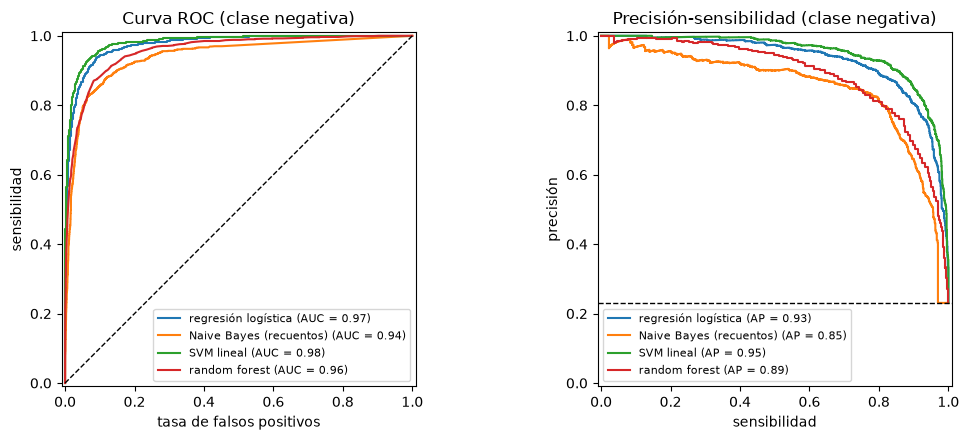

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for name in ["regresión logística", "Naive Bayes (recuentos)", "SVM lineal", "random forest"]:
    s = -scores(pipelines[name], X_test)                   # más alto = más negativa
    RocCurveDisplay.from_predictions(y_test, s, pos_label=0, name=name, ax=ax1)
    PrecisionRecallDisplay.from_predictions(y_test, s, pos_label=0, name=name, ax=ax2)
ax1.plot([0, 1], [0, 1], "k--", lw=1)
ax1.set(title="Curva ROC (clase negativa)", xlabel="tasa de falsos positivos", ylabel="sensibilidad")
ax2.axhline((y_test == 0).mean(), color="k", ls="--", lw=1)
ax2.set(title="Precisión-sensibilidad (clase negativa)", xlabel="sensibilidad", ylabel="precisión")
for ax in (ax1, ax2):
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

- En la curva ROC, los cuatro modelos están muy juntos (AUC entre 0,94 y 0,98): todos ordenan bien las reseñas.
- La curva de precisión-sensibilidad separa más: para detectar el 90 % de las negativas, el SVM mantiene una precisión cercana a 0,8 y Naive Bayes baja de 0,7. La línea discontinua es la precisión de un clasificador al azar (el 23 % de negativas); con la clase minoritaria como objetivo, esta curva es la más informativa.

### 3.4. Clases desequilibradas: pesos y umbral

Con la regresión logística probamos tres opciones para la clase negativa: los valores por defecto, `class_weight="balanced"` (los errores en negativas pesan $0{,}77/0{,}23 \approx 3{,}3$ veces más) y mover el umbral de probabilidad de 0,5 al que maximiza el F1 macro en una parte del entrenamiento reservada para validación (no en la prueba).

Umbral elegido en validación: 0.68


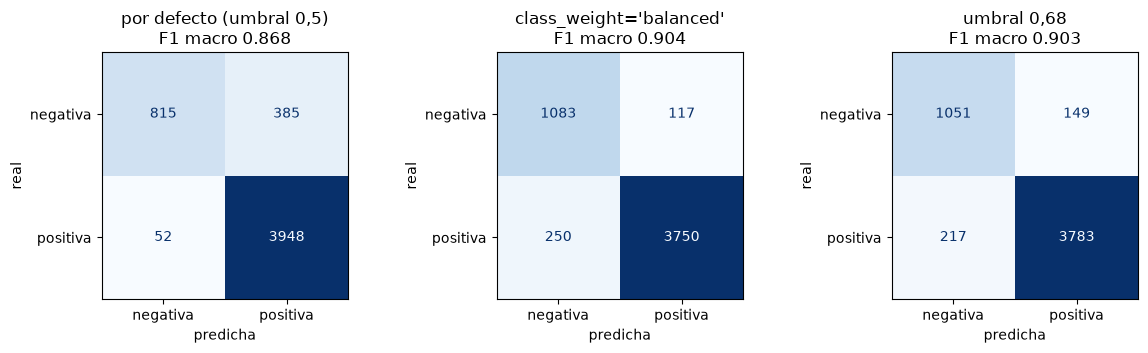

              precision    recall  f1-score   support

    negativa      0.812     0.902     0.855      1200
    positiva      0.970     0.938     0.953      4000

    accuracy                          0.929      5200
   macro avg      0.891     0.920     0.904      5200
weighted avg      0.933     0.929     0.931      5200



In [6]:
logreg = pipelines["regresión logística"]
balanced = make_pipeline(tfidf(), LogisticRegression(max_iter=1_000, class_weight="balanced")).fit(X_train, y_train)

# Umbral elegido con una partición de validación dentro del entrenamiento
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
tuned = make_pipeline(tfidf(), LogisticRegression(max_iter=1_000)).fit(X_fit, y_fit)
thresholds = np.linspace(0.3, 0.9, 61)
val_proba = tuned.predict_proba(X_val)[:, 1]
best_t = thresholds[np.argmax([f1_score(y_val, (val_proba >= t).astype(int), average="macro") for t in thresholds])]
print(f"Umbral elegido en validación: {best_t:.2f}")

predictions = {
    "por defecto (umbral 0,5)": logreg.predict(X_test),
    "class_weight='balanced'": balanced.predict(X_test),
    f"umbral {best_t:.2f}".replace(".", ","): (tuned.predict_proba(X_test)[:, 1] >= best_t).astype(int),
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["negativa", "positiva"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set(title=f"{name}\nF1 macro {f1_score(y_test, y_pred, average='macro'):.3f}",
           xlabel="predicha", ylabel="real")
plt.tight_layout()
plt.show()

print(classification_report(y_test, predictions["class_weight='balanced'"], target_names=["negativa", "positiva"], digits=3))

- Con el umbral por defecto, la regresión logística deja 385 de las 1 200 negativas sin detectar. Con `class_weight="balanced"` pasan a ser 117 (sensibilidad 0,902), a cambio de 198 falsos negativos más entre las positivas; el F1 macro sube de 0,868 a 0,904.
- Mover el umbral a 0,68 (elegido en validación) logra casi lo mismo (F1 macro 0,903) sin reentrenar. Las dos son formas de elegir un punto distinto de la misma curva ROC.
- Qué punto elegir depende del coste de cada error: para un negocio que quiere enterarse de las críticas, perder una negativa cuesta más que revisar una positiva de más.

### 3.5. Qué ha aprendido el modelo

En la regresión logística, cada término tiene un coeficiente: los más negativos empujan hacia «negativa» y los más positivos hacia «positiva».

In [7]:
vocab = balanced.named_steps["tfidfvectorizer"].get_feature_names_out()
coefs = balanced.named_steps["logisticregression"].coef_[0]
order = np.argsort(coefs)
pd.DataFrame({"hacia negativa": [f"{vocab[i]} ({coefs[i]:.1f})" for i in order[:12]],
              "hacia positiva": [f"{vocab[i]} ({coefs[i]:.1f})" for i in order[::-1][:12]]},
             index=range(1, 13))

,hacia negativa,hacia positiva
1,not (-8.9),great (9.5)
2,worst (-5.7),amazing (6.6)
3,horrible (-5.3),love (6.5)
4,no (-5.1),delicious (6.5)
5,terrible (-5.0),awesome (5.2)
6,ok (-4.6),best (5.1)
7,bland (-4.5),the best (4.6)
8,bad (-4.5),always (4.4)
9,rude (-4.4),definitely (4.4)
10,the worst (-4.2),perfect (4.2)


In [8]:
examples = ["The food was bland and the service was mediocre and the atmosphere was disappointing.",
            "The food was not good.",
            "Not bad at all, I would come back.",
            "I expected the worst, but the pizza was amazing."]
proba = balanced.predict_proba(examples)[:, 1]
for text, p in zip(examples, proba):
    print(f"P(positiva) = {p:.2f}  {text}")

# Errores más seguros: reseñas mal clasificadas con mayor probabilidad
test_proba = balanced.predict_proba(X_test)[:, 1]
errors = pd.DataFrame({"texto": X_test, "real": y_test, "P(positiva)": test_proba})
errors = errors[(errors["P(positiva)"] >= 0.5).astype(int) != errors["real"]]
errors["confianza"] = (errors["P(positiva)"] - 0.5).abs()
print(f"\nErrores: {len(errors)} de {len(X_test)}")
for _, row in errors.nlargest(3, "confianza").iterrows():
    print(f"\n[real {row['real']}, P(positiva) {row['P(positiva)']:.2f}] {row['texto'][:300]}")

P(positiva) = 0.02  The food was bland and the service was mediocre and the atmosphere was disappointing.
P(positiva) = 0.01  The food was not good.
P(positiva) = 0.10  Not bad at all, I would come back.
P(positiva) = 0.17  I expected the worst, but the pizza was amazing.



Errores: 367 de 5200

[real 1, P(positiva) 0.06] As many people have previously mentioned, there needs to be half stars because I would probably rate this as a 3.5. My aunt really wanted to visit this buffet because it had been highly recommended by a friend of hers. We arrived at buffet at around 8p.m. and there was quite a line to get in. We wer

[real 1, P(positiva) 0.11] This dry-cleaners is close to my house. Although they advertise "Most items $2.50", several of mine were priced higher, with seemingly no rhyme or reason to it. The service was friendly, however, and they don't require pre-payment. One really notable thing that happened, however, was that the young 

[real 1, P(positiva) 0.11] I give this place 4 stars because of the staff's attentiveness and the degree of customer service they demonstrated at our last visit. There were two people at the register. I'll call them guy 1 and guy 2. Guy 1 was taking our order. When we ordered I asked if they had some sort of juice for

- Los pesos tienen sentido: hacia «negativa», *not*, *no*, *worst*, *horrible*, *bland*, *rude* y *money* (las quejas por el precio); hacia «positiva», *great*, *amazing*, *love*, *delicious*. Los bigramas también aparecen (*the worst*, *the best*). *not* es el término con más peso de todos: quitarlo sería un error (sección 4).
- La frase con la que en el análisis original el modelo fallaba (*the food was bland and the service was mediocre…*) aquí se clasifica bien, y también *the food was not good*.
- Pero la bolsa de palabras no entiende la **composición**: *not bad at all, I would come back* sale negativa (0,10) porque suma *not* y *bad*, y *I expected the worst, but the pizza was amazing* también (0,17). Los modelos que leen la secuencia ([deep learning](08-sentimientos-con-deep-learning.ipynb), [BERT](10-modelos-de-lenguaje-preentrenados.ipynb)) manejan mejor estos casos.
- Los errores más seguros son reseñas de 4 estrellas que cuentan sobre todo problemas («*I would probably rate this as a 3.5*»): parte del error es ruido de las etiquetas, que ningún modelo puede eliminar.

### 3.6. Varias clases: AG News

Con más de dos clases, los clasificadores lineales entrenan un modelo por clase (uno contra el resto) y las métricas se calculan por clase. Usamos el SVM lineal, el mejor en reseñas.

In [9]:
with contextlib.redirect_stderr(io.StringIO()):
    ag_news = load_dataset("fancyzhx/ag_news", cache_dir="data")
class_names = ag_news["train"].features["label"].names
news_train, news_test = ag_news["train"].to_pandas(), ag_news["test"].to_pandas()
print(f"Entrenamiento: {len(news_train):,} · prueba: {len(news_test):,} · clases: {class_names}")
print(news_train["text"].iloc[0])

news_model = make_pipeline(tfidf(), LinearSVC()).fit(news_train["text"], news_train["label"])
news_pred = news_model.predict(news_test["text"])
print(classification_report(news_test["label"], news_pred, target_names=class_names, digits=3))

Entrenamiento: 120,000 · prueba: 7,600 · clases: ['World', 'Sports', 'Business', 'Sci/Tech']
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


              precision    recall  f1-score   support

       World      0.939     0.915     0.927      1900
      Sports      0.958     0.986     0.971      1900
    Business      0.906     0.898     0.902      1900
    Sci/Tech      0.910     0.915     0.913      1900

    accuracy                          0.929      7600
   macro avg      0.928     0.929     0.928      7600
weighted avg      0.928     0.929     0.928      7600



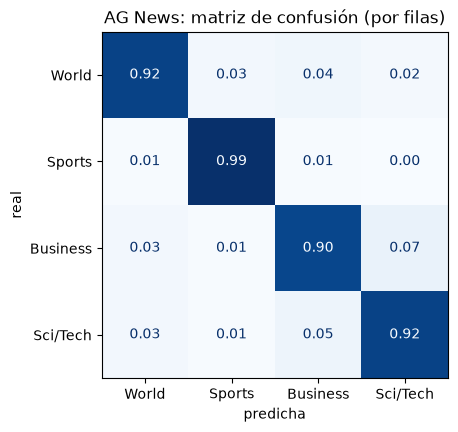

In [10]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(news_test["label"], news_pred, display_labels=class_names,
                                        normalize="true", values_format=".2f", cmap="Blues", colorbar=False, ax=ax)
ax.set(title="AG News: matriz de confusión (por filas)", xlabel="predicha", ylabel="real")
plt.show()

- Con cuatro clases equilibradas, la exactitud (0,929) y los promedios macro y ponderado coinciden. Las métricas por clase muestran dónde está la dificultad: *Sports* casi no se confunde (0,99 de sensibilidad), y la confusión principal es entre *Business* y *Sci/Tech* (el 7 % de las noticias de economía se clasifican como tecnología, y el 5 % al revés): noticias de empresas tecnológicas que podrían ir en cualquiera de las dos.
- Con un SVM lineal y TF-IDF se llega al 93 % en 12 segundos de entrenamiento: la línea base que una red neuronal tendría que superar.

## 4. Parámetros importantes y errores comunes

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| `ngram_range` (vectorizador) | Unigramas, bigramas… | `(1, 2)` casi siempre mejora: captura *not good*, *no flavor* |
| `min_df`, `sublinear_tf` | Vocabulario y peso de las repeticiones | `min_df` 2–5; `sublinear_tf=True` suele ayudar con textos largos |
| `C` (`LogisticRegression`, `LinearSVC`) | Inverso de la regularización | 0,1–10; búscalo con validación cruzada (`GridSearchCV` sobre el `Pipeline`) |
| `alpha` (`MultinomialNB`) | Suavizado de Laplace | 0,1–1; úsalo con recuentos, no con TF-IDF |
| `class_weight` | Peso de cada clase en la pérdida | `"balanced"` con clases desequilibradas |
| Umbral de decisión | Compromiso precisión-sensibilidad | Elígelo con validación según el coste de cada error, no en el conjunto de prueba |
| `n_estimators`, `max_features` (*random forest*) | Número de árboles y palabras por división | Con texto rara vez compensa; si se usa, cientos de árboles |

**Errores comunes y lecciones aprendidas**

- **Fiarse de la exactitud con clases desequilibradas.** En un análisis propio de reseñas de restaurantes de Yelp (77 % positivas), una regresión logística con TF-IDF obtuvo un 0,86 de exactitud que parecía bueno, pero la sensibilidad en las negativas era de 0,43: dejaba pasar el 57 % de las críticas. Aquí, el clasificador trivial ya tiene un 0,77 de exactitud con sensibilidad 0 en las negativas (sección 3.1). Mira siempre las métricas por clase o el F1 macro, y corrige con `class_weight` o con el umbral (sección 3.4).
- **Quitar las negaciones con las palabras vacías.** En ese análisis, el vectorizador quitaba las palabras vacías de NLTK, que incluyen *not*. Con esa lista, el modelo pierde F1 y clasifica *the food was not good* como positiva (demo abajo).
- **Ajustar el vectorizador antes de separar.** También allí se ajustó el TF-IDF con todo el corpus y después se separaron entrenamiento y prueba, una fuga de información (ver [TF-IDF](03-representacion-vectorial-tfidf.ipynb)). Con el `Pipeline`, `fit` solo ve el entrenamiento, también dentro de la validación cruzada.
- **Evaluar con etiquetas y predicciones desalineadas.** En otro trabajo, una red recurrente para AG News daba un 96 % de exactitud en validación y un 25 % (el azar con cuatro clases) en la prueba. El modelo estaba bien: las etiquetas reales se sacaban recorriendo el conjunto de prueba una vez y las predicciones recorriéndolo otra, y el conjunto se volvía a barajar en cada recorrido, así que no correspondían a los mismos documentos. Una exactitud de prueba igual a la del azar con una validación buena es la señal: comprueba que etiquetas y predicciones salen **en el mismo recorrido** y en el mismo orden (demo abajo).
- **Usar Naive Bayes con TF-IDF y clases desequilibradas.** Con TF-IDF y la clase mayoritaria tres veces más frecuente, Naive Bayes predice casi siempre «positiva» (sección 3.1); con recuentos funciona bien.
- **Elegir el modelo por diferencias pequeñas en una partición.** Compara con validación cruzada y mira la variación entre pliegues antes de decir que un modelo es mejor (sección 3.2).

In [11]:
# 1) Palabras vacías de NLTK (incluyen "not", "no", "nor")
with_stop = make_pipeline(TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True,
                                          stop_words=stopwords.words("english")),
                          LogisticRegression(max_iter=1_000, class_weight="balanced")).fit(X_train, y_train)
for name, model in [("sin quitar palabras vacías", balanced), ("con palabras vacías de NLTK", with_stop)]:
    y_pred = model.predict(X_test)
    print(f"{name:<28} F1 macro {f1_score(y_test, y_pred, average='macro'):.3f} · "
          f"'The food was not good.' -> {'positiva' if model.predict(['The food was not good.'])[0] else 'negativa'}")

# 2) Etiquetas y predicciones de recorridos distintos de un conjunto que se baraja en cada recorrido
rng = np.random.default_rng(42)
order_labels = rng.permutation(len(news_test))             # orden del recorrido en que se leen las etiquetas
order_preds = rng.permutation(len(news_test))              # orden del recorrido en que se predice
y_true_shuffled = news_test["label"].to_numpy()[order_labels]
y_pred_shuffled = news_model.predict(news_test["text"].iloc[order_preds])
print(f"\nAG News, etiquetas y predicciones alineadas:    {accuracy_score(news_test['label'], news_pred):.3f}")
print(f"AG News, etiquetas y predicciones desalineadas: {accuracy_score(y_true_shuffled, y_pred_shuffled):.3f}")

sin quitar palabras vacías   F1 macro 0.904 · 'The food was not good.' -> negativa


con palabras vacías de NLTK  F1 macro 0.886 · 'The food was not good.' -> positiva



AG News, etiquetas y predicciones alineadas:    0.929
AG News, etiquetas y predicciones desalineadas: 0.242


## 5. Comparación con métodos relacionados

| Modelo | Ventajas | Inconvenientes | Cuándo usarlo |
|---|---|---|---|
| Regresión logística + TF-IDF | Probabilidades calibradas razonablemente; coeficientes interpretables; rápida | Lineal: no capta interacciones salvo con n-gramas | Línea base por defecto; cuando hace falta explicar |
| SVM lineal + TF-IDF | Suele ser el más preciso de los clásicos; rápido | Sin probabilidades (hay que calibrar); umbral sobre una puntuación | Máximo rendimiento con modelos clásicos |
| Naive Bayes + recuentos | Rapidísimo; bueno con muy pocos datos y textos cortos | Supuesto de independencia; probabilidades extremas | Línea base rápida, flujos de datos, pocos ejemplos |
| *Random forest* / *boosting* + TF-IDF | Capta interacciones | Lentos y peores con miles de dimensiones dispersas | Con variables no textuales añadidas, o pocas dimensiones (tras reducirlas) |
| Redes recurrentes con embeddings ([sentimientos con deep learning](08-sentimientos-con-deep-learning.ipynb)) | Tienen en cuenta el orden de las palabras | Necesitan más datos y ajuste; poco interpretables | Muchos datos etiquetados, orden importante |
| *Fine-tuning* de un modelo preentrenado ([BERT](10-modelos-de-lenguaje-preentrenados.ipynb)) | Lo mejor en casi todas las tareas, también con pocos datos | Coste de cómputo; GPU | Cuando el rendimiento importa más que el coste |

## 6. Referencias

### Fuentes

- Zhang, X., Zhao, J. y LeCun, Y. (2015). «Character-level convolutional networks for text classification». *Advances in Neural Information Processing Systems 28 (NIPS 2015)*, 649–657. Origen de Yelp Review Full y AG News en su versión de clasificación, descargados de Hugging Face ([`Yelp/yelp_review_full`](https://huggingface.co/datasets/Yelp/yelp_review_full), [`fancyzhx/ag_news`](https://huggingface.co/datasets/fancyzhx/ag_news)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- scikit-learn: [Working with text data](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html), [`Pipeline`](https://scikit-learn.org/stable/modules/compose.html#pipeline), [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), [`MultinomialNB`](https://scikit-learn.org/stable/modules/naive_bayes.html#multinomial-naive-bayes), [`LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html), [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) y [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html).
- NLTK: [corpus de palabras vacías](https://www.nltk.org/nltk_data/).

### Para saber más

- Jurafsky, D. y Martin, J. H. (2026). [*Speech and Language Processing*](https://web.stanford.edu/~jurafsky/slp3/) (3.ª ed., borrador en línea). El capítulo 4 (*Logistic Regression and Text Classification*) explica la clasificación de texto con regresión logística, sus características y su evaluación (precisión, sensibilidad, F1, validación cruzada y tests estadísticos para comparar clasificadores) y cómo interpretar los pesos del modelo.
- Wang, S. y Manning, C. D. (2012). «Baselines and bigrams: Simple, good sentiment and topic classification». *Proceedings of the 50th Annual Meeting of the ACL (Volume 2: Short Papers)*, 90–94. Muestra que Naive Bayes y SVM con bigramas son líneas base muy difíciles de batir en sentimientos y temas, y cuándo gana cada uno.